In [31]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np




In [32]:

# Load data
df = pd.read_csv("data\AABA_2006-01-01_to_2018-01-01.csv")
# Choosing the "closed" because that is more relevant? I dont know anything abut stocks
price_closed_raw = df["Close"].values


<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
C:\Users\rasmu\AppData\Local\Temp\ipykernel_32696\1054775127.py:2: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("data\AABA_2006-01-01_to_2018-01-01.csv")


In [33]:
# This is only optional, and is for clarity when viewing the graphs.
# I limit the data to only the first 200 instances to get a better view.
# You can disable it to get the full dataset.
price_closed_raw = price_closed_raw[:200]

In [34]:
# Remove the offset so the mean is around 0. Better for fft.
mean_value = np.mean(price_closed_raw)
price_closed = price_closed_raw - mean_value

By removing the offset, it centers the data around the x-axis. This is a good step to do when doing a fourier transformation.

In [35]:
# Fourier transformation. I use FFT (Fourier Fast Transformation) which is
# a more effecient method for doing Discrete Fourier Transformation
fft_values = np.fft.fft(price_closed)
frequencies = np.fft.fftfreq(len(price_closed))


In [36]:
# Making sure that we only get the positive values.  
pos_only = frequencies > 0
amp = np.abs(fft_values[pos_only])
freqs_pos = frequencies[pos_only]

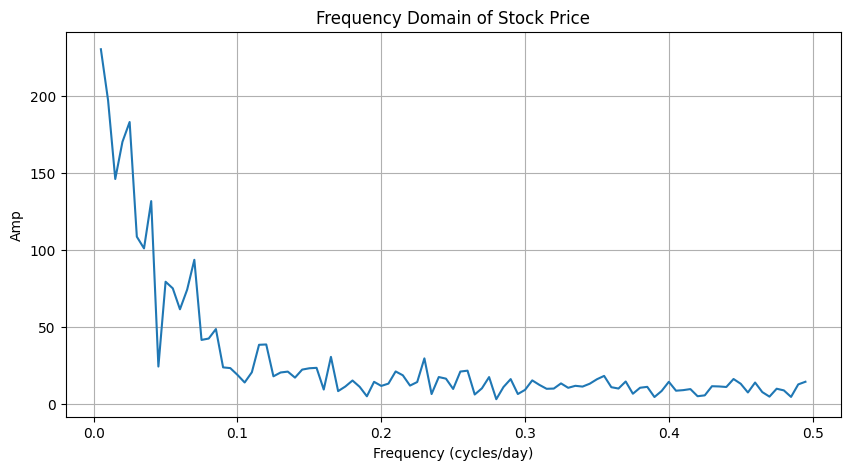

In [37]:
# Plot of the frequency domain, so we can choose an acceptable cutoff point 
# from visualizing the graph.
plt.figure(figsize=(10, 5))
plt.plot(freqs_pos, amp, label="FFT Amplitude Spectrum")
plt.title("Frequency Domain of Stock Price")
plt.xlabel("Frequency (cycles/day)")
plt.ylabel("Amp")
plt.grid(True)
plt.show()

I zoomed in alot on this graph, but the best cutoff (steep drop) is around 0.01 and 0.05. I choose 0.05 as it smooths out the raw data the best. 

In [38]:
# Choose low-pass to reduce the noise. 
cutoff = 0.05 # Chosen from looking at frequency domain, was a aggresive dropoff at start
filtered_fft = fft_values.copy()
filtered_fft[np.abs(frequencies > cutoff)] = 0 # Filter (low pass)



In [39]:
# Inverse FFT to go back from frequency domain with filtered data.
# Also adds back mean value to get correct prices.
filtered_price = np.fft.ifft(filtered_fft).real + mean_value



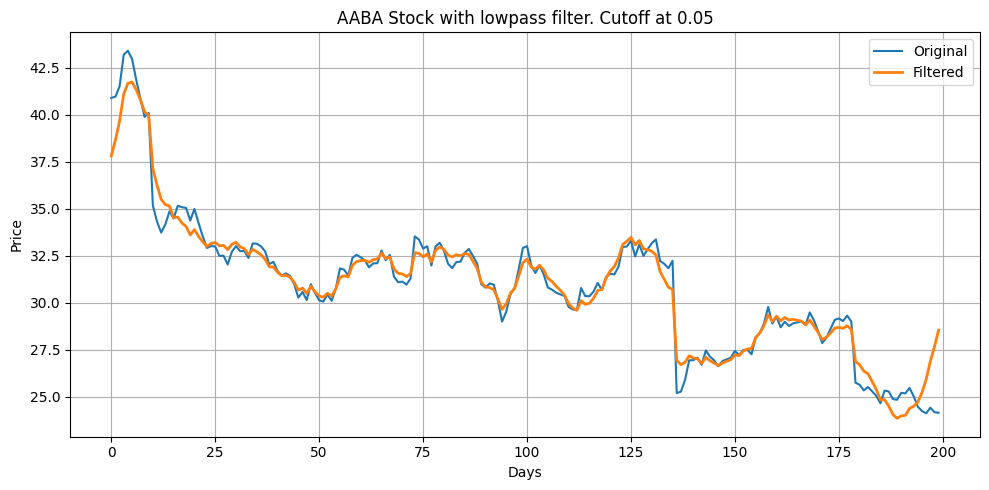

In [40]:
# Plot a graph that contains the original data vs the filtered data.
# Still not the best filtered data, but that depends how much of the patterns
# you want to keep. 
plt.figure(figsize=(10, 5))
plt.plot(price_closed_raw, label = "Original")
plt.plot(filtered_price, label = "Filtered", linewidth=2)
plt.legend()
plt.xlabel("Days")
plt.ylabel("Price")
plt.title(f"AABA Stock with lowpass filter. Cutoff at {cutoff}")
plt.grid(True)
plt.tight_layout()
plt.show()
